# 03 - Model Interpretation
**Capstone Project - Pembelajaran Mesin**

Interpretasi model terbaik menggunakan Permutation Importance & SHAP.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import joblib, json

best_pipeline = joblib.load('../models/best_model.pkl')
metadata = json.load(open('../models/metadata.json'))
print('Model terbaik:', metadata['best_model'])

Model terbaik: Linear Regression


In [2]:
df = pd.read_csv('../data/processed/cafe_sales_clean.csv')
from sklearn.model_selection import train_test_split
NUMERIC_FEATURES = metadata['numeric_features']
CATEGORICAL_FEATURES = metadata['categorical_features']
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[metadata['target']]
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

## 1. Permutation Importance

In [3]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
importance_df = pd.DataFrame({
    'feature': NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)
importance_df

,feature,importance_mean,importance_std
5,Item,0.763184,0.039081
2,Month,0.004467,0.000901
0,Inflasi,0.004177,0.001064
3,DayOfWeek,0.000571,0.000542
7,Location,0.000108,0.000213
1,Year,0.000000,0.000000
4,IsWeekend,-0.000100,0.000600
6,Payment Method,-0.000124,0.000546


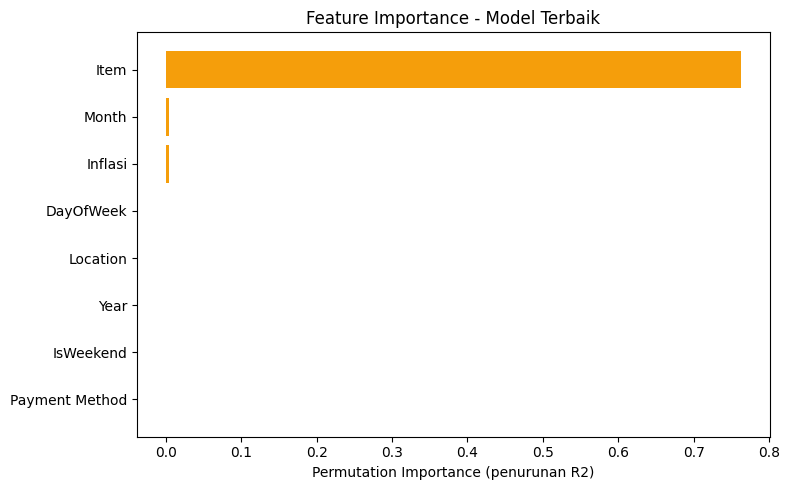

In [4]:
plt.figure(figsize=(8,5))
plt.barh(importance_df['feature'], importance_df['importance_mean'], color='#f59e0b')
plt.gca().invert_yaxis()
plt.xlabel('Permutation Importance (penurunan R2)')
plt.title('Feature Importance - Model Terbaik')
plt.tight_layout()
plt.show()

**Interpretasi:** `Item` (jenis menu yang dipilih) adalah fitur paling berpengaruh terhadap prediksi `Total Spent`, jauh di atas fitur lain. Ini masuk akal secara bisnis karena setiap menu memiliki rentang harga dasar yang berbeda. Fitur waktu (`Month`, `DayOfWeek`) dan `Inflasi` memiliki pengaruh yang jauh lebih kecil, mengonfirmasi temuan EDA bahwa penjualan kafe relatif resilient terhadap perubahan makroekonomi.

## 2. SHAP Values (untuk model Random Forest)

In [5]:
import shap
import joblib

rf_model = joblib.load('../models/random_forest_model.pkl')
preprocessor = rf_model.named_steps['preprocessor']
regressor = rf_model.named_steps['model']

X_test_sample = X_test.sample(min(200, len(X_test)), random_state=42)
X_test_transformed = preprocessor.transform(X_test_sample)
feature_names_out = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(regressor)
shap_values = explainer.shap_values(X_test_transformed)
print('SHAP values shape:', shap_values.shape)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (200, 20)


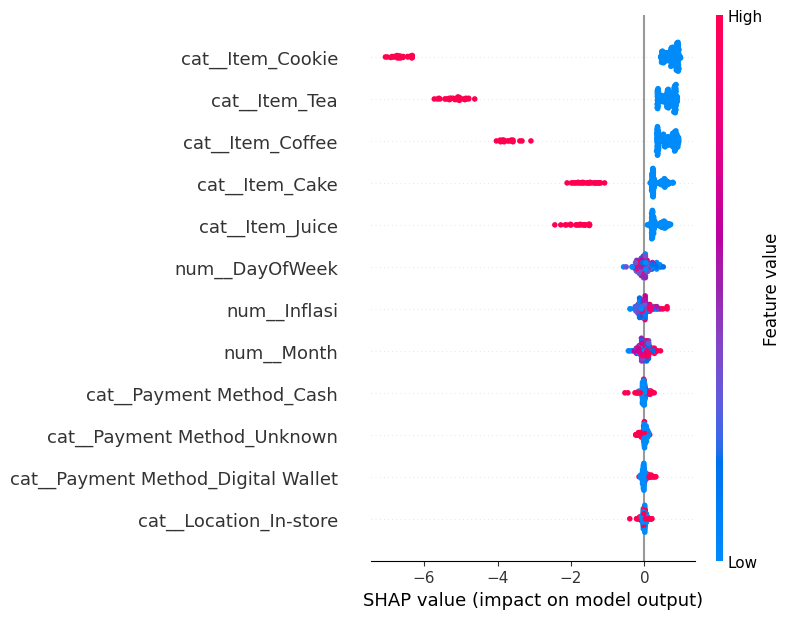

In [6]:
shap.summary_plot(
    shap_values, X_test_transformed, feature_names=feature_names_out,
    show=False, max_display=12
)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretasi SHAP:** Ringkasan SHAP mengonfirmasi bahwa kategori `Item` (hasil one-hot encoding) mendominasi kontribusi terhadap prediksi, konsisten dengan hasil permutation importance. Fitur numerik seperti `Inflasi` dan `Month` memberikan kontribusi yang jauh lebih kecil dan lebih tersebar (variasi SHAP value rendah), menunjukkan efek yang lemah dan tidak konsisten terhadap prediksi nilai belanja.

## Kesimpulan Interpretasi
1. Pilihan menu (`Item`) adalah pendorong utama nilai belanja pelanggan.
2. Konteks waktu (bulan, hari) dan payment method memberi pengaruh kecil namun tetap terukur.
3. Inflasi bulanan **bukan** prediktor kuat -- mendukung insight bisnis bahwa kafe ini relatif tahan terhadap gejolak ekonomi makro, sehingga strategi penjualan bisa lebih difokuskan pada bauran menu & customer experience ketimbang mitigasi risiko makroekonomi.